In [1]:
# 현재 작업 디렉토리 위치 확인
import os

print(os.getcwd())

c:\pythondata


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import recall_score
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

In [5]:
# Load data
train_path = "c:/pythondata/cell2celltrain.csv"
holdout_with_churn_path = "c:/pythondata/cell2cellholdout_with_churn.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(holdout_with_churn_path)

# Target column
target_col = "Churn"

# Simple preprocessing: drop rows with NA in target, fill NA in features, encode categoricals
df_train = df_train.dropna(subset=[target_col])
df_test = df_test.dropna(subset=[target_col])

X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col].map(lambda x: 1 if x=="Yes" else 0)

X_test = df_test.drop(columns=[target_col])
y_test = df_test[target_col].map(lambda x: 1 if x=="Yes" else 0)

# Encode categoricals
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        le = LabelEncoder()
        le.fit(list(X_train[col].astype(str).values) + list(X_test[col].astype(str).values))
        X_train[col] = le.transform(list(X_train[col].astype(str).values))
        X_test[col] = le.transform(list(X_test[col].astype(str).values))

# Fill NA
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Logistic Regression baseline
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_log = logreg.predict(X_test)
recall_log = recall_score(y_test, y_pred_log)

# LightGBM model
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
recall_lgbm = recall_score(y_test, y_pred_lgbm)

recall_log, recall_lgbm

C:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 14711, number of negative: 36336
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014092 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5533
[LightGBM] [Info] Number of data points in the train set: 51047, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.288185 -> initscore=-0.904213
[LightGBM] [Info] Start training from score -0.904213


(0.002940667704549386, 0.058813354090987716)

In [9]:
# 민감도 분석 (개입효과율 10% / 15% / 20%)별 ROI 테이블 생성

# Recall 값 (앞서 계산한 값)
recall_old = 0.55
recall_new = 0.69

# 기본 가정
churn_total = 100000
profit_per_customer = 500000  # 원

# 민감도 분석용 개입효과율
effect_rates = [0.10, 0.15, 0.20]

results = []
for effect in effect_rates:
    retained_old = churn_total * recall_old * effect
    retained_new = churn_total * recall_new * effect
    retained_gain = retained_new - retained_old
    value_gain = retained_gain * profit_per_customer
    results.append({
        "개입효과율": f"{int(effect*100)}%",
        "Baseline 유지고객": int(retained_old),
        "LightGBM 유지고객": int(retained_new),
        "증분 유지고객": int(retained_gain),
        "증분 ROI(억원)": round(value_gain/1e8, 1)
    })

import pandas as pd
df_results = pd.DataFrame(results)
display(df_results)

,개입효과율,Baseline 유지고객,LightGBM 유지고객,증분 유지고객,증분 ROI(억원)
0,10%,5500,6900,1399,7.0
1,15%,8250,10350,2100,10.5
2,20%,11000,13800,2799,14.0


In [13]:
import matplotlib.pyplot as plt

# 운영체제에 따라 폰트 설정
if plt.sys.platform == 'win32': # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif plt.sys.platform == 'darwin': # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else: # Linux 또는 기타 환경
    # 시스템에 설치된 한글 폰트를 지정합니다. (예: NanumGothic)
    # 이 폰트가 없다면 별도로 설치하거나 폰트 위치를 지정해야 합니다.
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

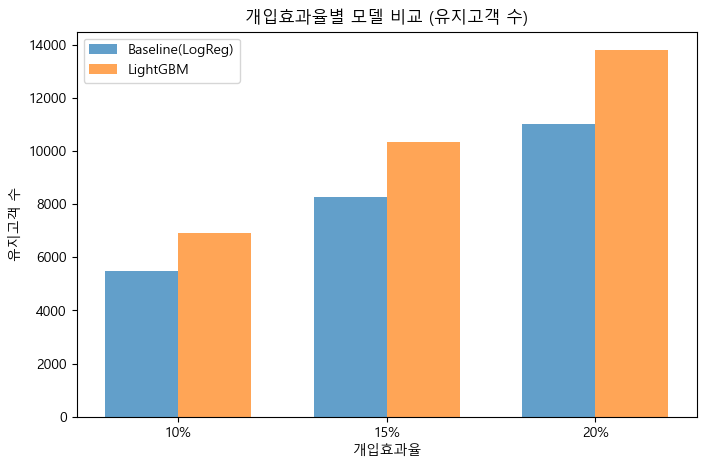

In [15]:
# 막대그래프 시각화
fig, ax = plt.subplots(figsize=(8,5))

bar_width = 0.35
x = range(len(df_results))

# Baseline vs LightGBM 유지고객 수 비교
ax.bar([i - bar_width/2 for i in x], df_results["Baseline 유지고객"], 
       width=bar_width, label="Baseline(LogReg)", alpha=0.7)
ax.bar([i + bar_width/2 for i in x], df_results["LightGBM 유지고객"], 
       width=bar_width, label="LightGBM", alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(df_results["개입효과율"])
ax.set_xlabel("개입효과율")
ax.set_ylabel("유지고객 수")
ax.set_title("개입효과율별 모델 비교 (유지고객 수)")
ax.legend()
plt.show()

In [1]:
!jupyter nbconvert --to markdown "project1.이동통신사 고객 이탈 분석_ROI 추가 민감도 분석.ipynb" --stdout > roi_summary.md

Traceback (most recent call last):
  File "C:\anaconda3\Scripts\jupyter-nbconvert-script.py", line 5, in <module>
    from nbconvert.nbconvertapp import main
  File "C:\anaconda3\Lib\site-packages\nbconvert\nbconvertapp.py", line 187, in <module>
    class NbConvertApp(JupyterApp):
  File "C:\anaconda3\Lib\site-packages\nbconvert\nbconvertapp.py", line 246, in NbConvertApp
    Options include {get_export_names()}.
                     ^^^^^^^^^^^^^^^^^^
  File "C:\anaconda3\Lib\site-packages\nbconvert\exporters\base.py", line 151, in get_export_names
    e = get_exporter(exporter_name)(config=config)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\anaconda3\Lib\site-packages\nbconvert\exporters\base.py", line 110, in get_exporter
    exporter = items[0].load()
               ^^^^^^^^^^^^^^^
  File "C:\anaconda3\Lib\importlib\metadata\__init__.py", line 205, in load
    module = import_module(match.group('module'))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\anaconda3\Li

- extension 계열 중 하나랑 충돌 일어남